In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/mock_ige_cytokine_behavior.csv')

In [2]:
# WHY median, not mean? Because cytokine data is skewed (a few very high outlier values),
# and the median is not affected by extreme outliers the way the mean is.
df['IL10_pg_mL'] = df['IL10_pg_mL'].fillna(df['IL10_pg_mL'].median())
df['TNFa_pg_mL'] = df['TNFa_pg_mL'].fillna(df['TNFa_pg_mL'].median())

In [3]:
print(df.isnull().sum())

subject_id        0
age               0
sex               0
IgE_IU_mL         0
IL4_pg_mL         0
IL6_pg_mL         0
IL10_pg_mL        0
TNFa_pg_mL        0
IFNg_pg_mL        0
behavior_score    0
behavior_group    0
dtype: int64


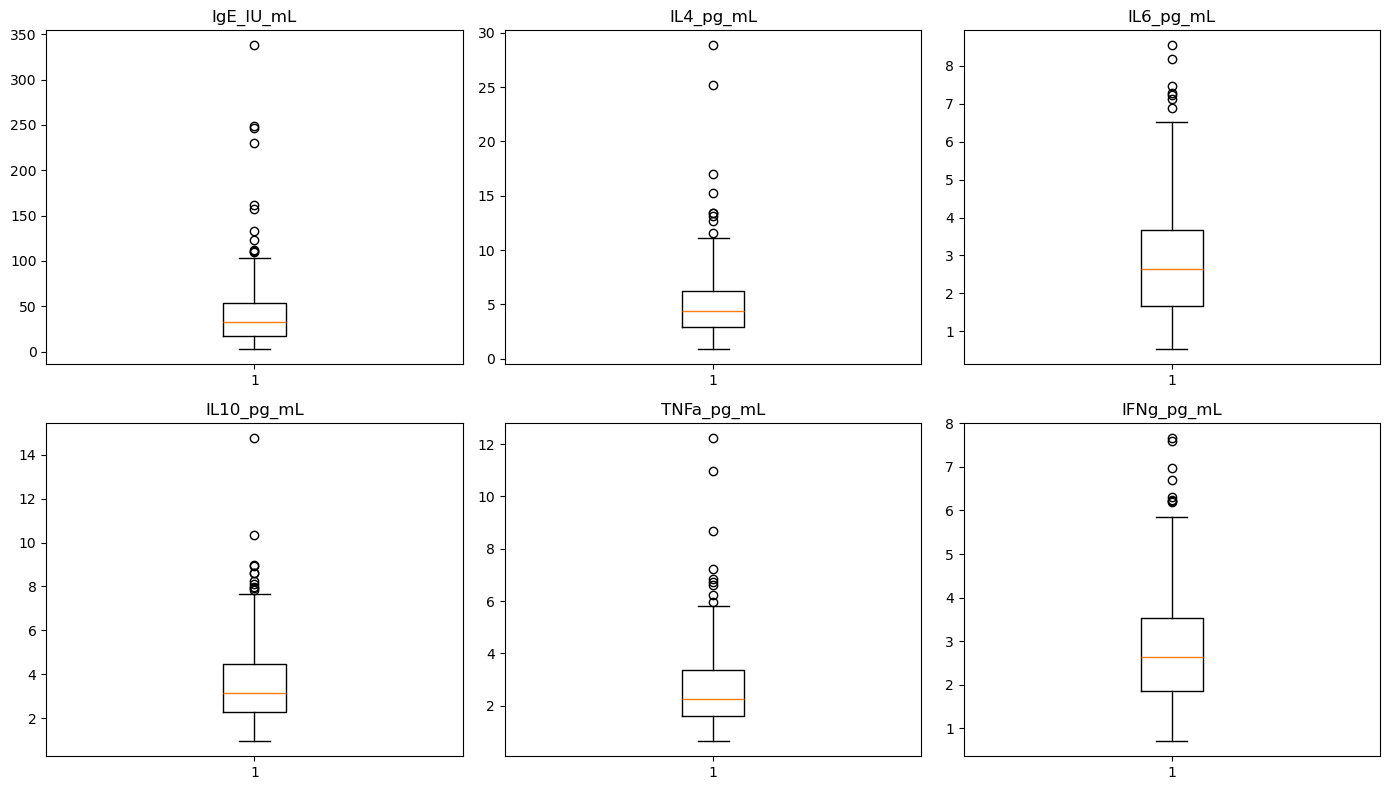

In [5]:
import matplotlib.pyplot as plt

cytokine_cols = ['IgE_IU_mL','IL4_pg_mL','IL6_pg_mL','IL10_pg_mL','TNFa_pg_mL','IFNg_pg_mL']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cytokine_cols):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
for col in cytokine_cols:
    df[col + '_log'] = np.log1p(df[col]) # log1p = log(x+1), safely handles zeros

KeyError: 'IgE_IU_mL_log'

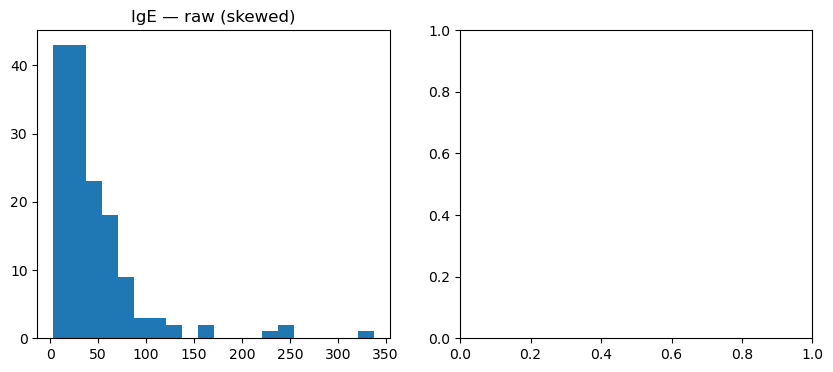

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['IgE_IU_mL'], bins=20)
axes[0].set_title('IgE — raw (skewed)')
axes[1].hist(df['IgE_IU_mL_log'], bins=20)
axes[1].set_title('IgE — log-transformed (more normal)')
plt.show()

In [10]:
df.columns.tolist()

['subject_id',
 'age',
 'sex',
 'IgE_IU_mL',
 'IL4_pg_mL',
 'IL6_pg_mL',
 'IL10_pg_mL',
 'TNFa_pg_mL',
 'IFNg_pg_mL',
 'behavior_score',
 'behavior_group',
 'IFNg_pg_mL_log',
 'IgE_IU_mL_log',
 'IL4_pg_mL_log',
 'IL6_pg_mL_log',
 'IL10_pg_mL_log',
 'TNFa_pg_mL_log']

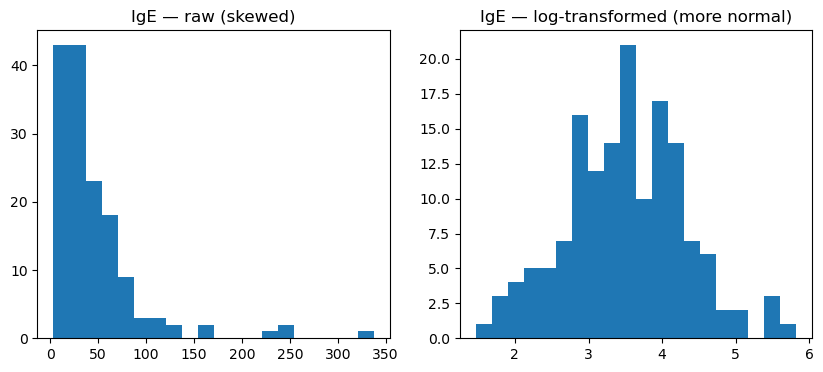

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['IgE_IU_mL'], bins=20)
axes[0].set_title('IgE — raw (skewed)')
axes[1].hist(df['IgE_IU_mL_log'], bins=20)
axes[1].set_title('IgE — log-transformed (more normal)')
plt.show()

In [12]:
df.to_csv('data/cleaned_data.csv', index=False)
print("Saved cleaned_data.csv with shape", df.shape)

Saved cleaned_data.csv with shape (150, 17)
